# 3 - Wholesale Customer Segmentation - Clustering

<img src='https://www.tidio.com/wp-content/uploads/Customer-segmentation-min.png'>

Bu çalışmada toptan müşteri harcama verilerini kullanarak benzer satın alma davranışlarına sahip müşteri gruplarını belirleyen bir clustering modeli geliştireceğim.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Veriyi ölçekleme
6. Elbow yöntemi ile küme sayısı seçme
7. KMeans modeli kurma
8. PCA ile görselleştirme
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen toptan müşteri datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Wholesale Customers Data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'drive', 'Wholesale customers data.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde zip içinden çıkan csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [6]:
file_path = '/content/Wholesale customers data.csv'

df = pd.read_csv(file_path)
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [7]:
df.shape

(440, 8)

In [8]:
df.columns.tolist()

['Channel',
 'Region',
 'Fresh',
 'Milk',
 'Grocery',
 'Frozen',
 'Detergents_Paper',
 'Delicassen']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [10]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## 3. Veri Temizleme

In [11]:
# Bu bölümde boş veri kontrolü yapacağım.

In [12]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


## 4. Feature Engineering

In [13]:
# Bu bölümde tüm sütunları clustering için kullanacağım ve veri setini olduğu haliyle hazırlayacağım.

In [14]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 5. Veriyi Ölçekleme

In [15]:
# Bu bölümde clustering öncesi tüm değişkenleri aynı ölçeğe getireceğim.

In [16]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
x_scaled[:5]

array([[ 1.44865163,  0.59066829,  0.05293319,  0.52356777, -0.04111489,
        -0.58936716, -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197,  0.54445767,  0.17031835,
        -0.27013618,  0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926,  0.40853771, -0.0281571 ,
        -0.13753572,  0.13323164,  2.24329255],
       [-0.69029709,  0.59066829,  0.10011141, -0.62401993, -0.3929769 ,
         0.6871443 , -0.49858822,  0.09341105],
       [ 1.44865163,  0.59066829,  0.84023948, -0.05239645, -0.07935618,
         0.17385884, -0.23191782,  1.29934689]])

## 6. Elbow Yöntemi ile Küme Sayısı Seçme

In [17]:
# Bu bölümde en uygun küme sayısını seçmek için inertia değerlerini inceleyeceğim.

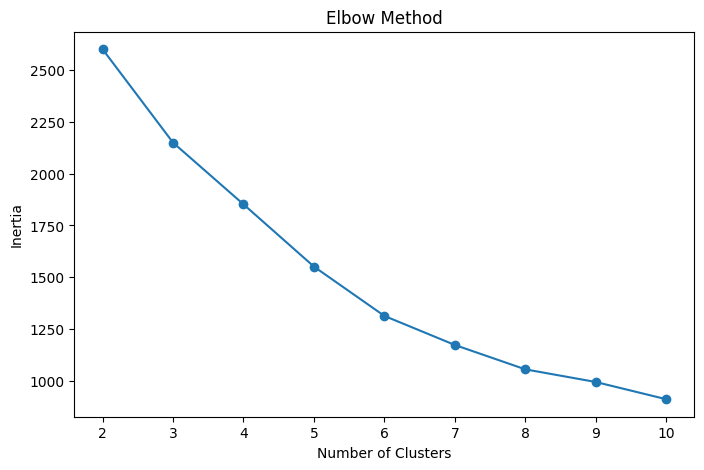

In [18]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

## 7. KMeans Modeli Kurma

In [19]:
# Bu bölümde seçilen küme sayısı ile KMeans modelini kuracağım ve segmentleri oluşturacağım.

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

df['Cluster'] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0


In [21]:
silhouette = silhouette_score(x_scaled, clusters)
silhouette

np.float64(0.34819485747460033)

## 8. PCA ile Görselleştirme

In [22]:
# Bu bölümde kümeleri iki boyutta görselleştirerek segmentlerin ayrışmasını inceleyeceğim.

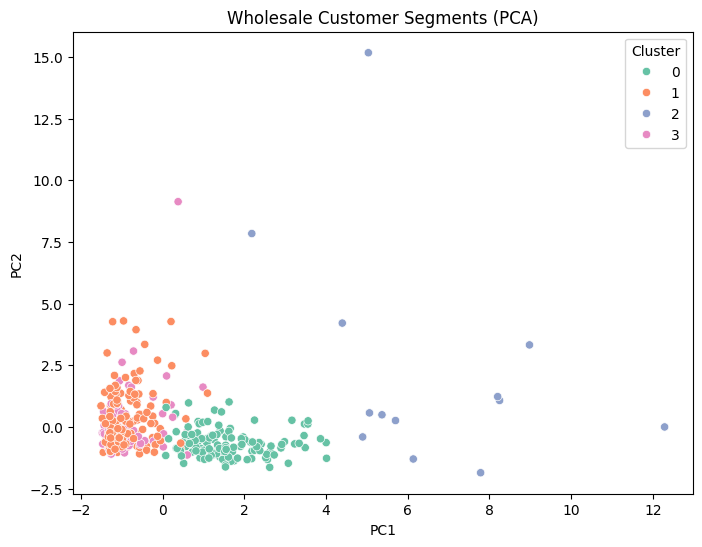

In [23]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title('Wholesale Customer Segments (PCA)')
plt.show()

## 9. Sonuç

Bu projede toptan müşteri harcama davranışlarına göre segmentasyon yapmak için KMeans clustering yöntemi kullanıldı. Elde edilen sonuçlara göre en uygun küme sayısı 4 oldu ve model 0.3482 silhouette score değeri elde etti.